## 环境配置
### 安装配置 R 语言环境

```
## 进入 R 编程环境
conda activate LabelTransfer

## 安装所需库
conda create -n LabelTransfer -c conda-forge \
r-base=4.3 \
hdf5 \
r-hdf5r \
r-seurat \
r-seuratobject \
r-arrow \
r-tidyverse \
r-ggplot2 \
r-ggpmisc \
r-cowplot \
r-gridextra \
r-viridis \
r-hrbrthemes \
r-jsonlite \
r-remotes
```

### 安装BPcells

```
## 下载 BPcells 包
cd ~
git clone https://github.com/bnprks/BPCells.git

## 进入 R 环境
R

## 使用本地编译安装
remotes::install_local("~/BPCells/r")
```

### 安装 ipynb 文件运行 R 所需库

```
## 安装所需库
conda install -c conda-forge \
r-irkernel \
jupyter \
notebook \
ipykernel

## 进入 R 注册 kernel
IRkernel::installspec(name = "LabelTransfer", displayname = "R_LabelTransfer")

##  数据准备

### 在终端中执行，进入你的工作目录

```
cd ./data/
wget https://s3-us-west-2.amazonaws.com/10x.files/samples/xenium/3.0.0/Xenium_V1_Human_Ovarian_Cancer_Addon_FFPE/Xenium_V1_Human_Ovarian_Cancer_Addon_FFPE_outs.zip
unzip Xenium_V1_Human_Ovarian_Cancer_Addon_FFPE_outs.zip
```

```
curl -O https://cf.10xgenomics.com/samples/cell-exp/8.0.1/17k_Ovarian_Cancer_scFFPE/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5
```

```
curl -O https://cf.10xgenomics.com/supp/cell-exp/FLEX_Ovarian_Barcode_Cluster_Annotation.csv
```

In [3]:
# ============================================
# Cell 1: 统一初始化 - 集中管理所有配置
# ============================================

setwd("/home/ailab/caohao/AdaDiss/")  # 按需修改
# setwd("/root/AdaDiss/")

# 1. 文件路径
paths <- list(
    project_root = "./",
    raw_data = list(
        flex = list(
            h5         = "./data/raw/flex/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5",
            annotation = "./data/raw/flex/FLEX_Ovarian_Barcode_Cluster_Annotation.csv"
        ),
        xenium = list(
            dir        = "./data/raw/xenium/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/",
            gene_panel = "./data/raw/xenium/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/gene_panel.json"
        )
    ),
    cache = list(
        flex                = "./data/cache/ovarian_flex_data_processed_enhanced.rds",
        xenium              = "./data/cache/ovarian_xenium_data_processed.rds",
        anchors_coarse      = "./data/cache/anchors_coarse.rds",
        anchors_fine        = "./data/cache/anchors_fine_list.rds",
        predictions_coarse  = "./data/cache/predictions_coarse.rds",
        predictions_fine    = "./data/cache/predictions_fine.rds"
    ),
    bpcells = list(
        flex   = "./data/bpcells/ovarian_flex_counts/",
        xenium = "./data/bpcells/ovarian_xenium_counts/"
    ),
    predictions = list(
        main = "./results/predictions/cell_groups_enhanced.csv",
        full = "./results/predictions/cell_predictions_full_enhanced.csv",
        for_gnn = "./results/exports/xenium_for_gnn_enhanced.csv",
        seurat_objects = list(
            xenium_annotated = "./results/seurat/xenium_annotated_final_enhanced.rds",
            flex_reference   = "./results/seurat/flex_reference_enhanced.rds"
        )
    ),
    backup = list(coordinates = "./data/backup/coordinates_backup_enhanced.csv"),
    seurat_lt_csv = "./results/predictions/seurat_label_transfer_ovarian_enhanced.csv",
    reports = list(
        stats = "./reports/prediction_stats_enhanced.txt",
        logs  = "./reports/logs/"
    ),
    plots = list(
        dir = "./plots/",
        subdirs = list(
            quality_control = "./plots/01_quality_control/",
            annotation      = "./plots/02_annotation/",
            validation      = "./plots/03_validation/",
            spatial         = "./plots/04_spatial/"
        )
    )
)

# 2. 创建所有目录
create_all_dirs <- function(paths) {
    dirs_to_create <- c(
        "./data/raw/flex/", "./data/raw/xenium/", "./data/cache/", "./data/backup/",
        "./data/bpcells/ovarian_flex_counts/", "./data/bpcells/ovarian_xenium_counts/",
        "./results/predictions/", "./results/exports/", "./results/seurat/",
        "./reports/logs/",
        "./plots/01_quality_control/", "./plots/02_annotation/",
        "./plots/03_validation/", "./plots/04_spatial/"
    )
    for (d in dirs_to_create) if (!dir.exists(d)) dir.create(d, recursive = TRUE)
}
create_all_dirs(paths)

# 3. 分析参数 - 关键调整
params <- list(
    # Flex QC
    flex_min_counts   = 200,
    flex_max_counts   = 10000,
    flex_max_mt       = 10,

    # Xenium QC - 修复：原版只过滤 nCount > 0，过于宽松
    xenium_min_counts   = 5,
    xenium_min_features = 3,

    # 主成分数 - 修复：Flex 和 Xenium 统一用 30 PCs
    n_pcs           = 30,
    flex_dims       = 1:30,        # 原版仅用 15
    xenium_npcs     = 50,
    xenium_dims     = 1:30,
    xenium_resolution = 0.6,
    xenium_cluster_name = "clusters",

    # 标签转移参数
    transfer_dims   = 1:30,
    transfer_k_filter = 200,       # 默认值
    transfer_k_score  = 30,
    transfer_k_weight = 50,        # 比默认 100 低，让转移更"决断"

    # 空间平滑参数
    spatial_k         = 15,        # 最近邻数
    spatial_threshold = 0.7,       # 低于此置信度才进行平滑
    spatial_consensus = 0.6,       # 至少 60% 邻居同意才更新

    # 输出阈值
    confidence_high   = 0.7,
    confidence_medium = 0.5,
    unassigned_threshold = 0.4,    # 低于此分配为 Unassigned

    seed = 42,
    verbose = TRUE
)

# 4. 细胞类型层级 - 核心创新
celltype_hierarchy <- list(
    "Tumor" = c(
        "Tumor Cells",
        "VEGFA+ Tumor Cells",
        "Proliferative Tumor Cells",
        "MT-High, Jun+/Fos+ Tumor Cells",
        "Inflammatory Tumor Cells",
        "Malignant Cells Lining Cyst"
    ),
    "Fibroblast" = c(
        "Tumor Associated Fibroblasts",
        "Stromal Associated Fibroblasts"
    ),
    "Vascular" = c(
        "Endothelial Cells",
        "Pericytes",
        "Smooth Muscle Cells"
    ),
    "Immune" = c(
        "Macrophages",
        "T & NK Cells"
    ),
    "Epithelial" = c(
        "Ciliated Epithelial Cells",
        "Fallopian Tube Epithelium",
        "Granulosa Cells"
    )
)

# 反向映射：fine_type → coarse_type
fine_to_coarse <- unlist(lapply(names(celltype_hierarchy), function(coarse) {
    setNames(rep(coarse, length(celltype_hierarchy[[coarse]])),
             celltype_hierarchy[[coarse]])
}))

cat("\n📋 细胞类型层级:\n")
for (coarse in names(celltype_hierarchy)) {
    cat(sprintf("  %s (%d 亚型):\n", coarse, length(celltype_hierarchy[[coarse]])))
    for (fine in celltype_hierarchy[[coarse]]) cat(sprintf("    - %s\n", fine))
}

# 5. Canonical markers（用于验证）- 仅使用 Xenium 480 panel 中可能存在的基因
# 实际可用基因将在加载 Xenium 后过滤
canonical_markers <- list(
    "Tumor Cells"                      = c("EPCAM", "KRT8", "KRT18", "PAX8", "WT1"),
    "VEGFA+ Tumor Cells"               = c("VEGFA", "EPCAM", "KRT8"),
    "Proliferative Tumor Cells"        = c("MKI67", "TOP2A", "EPCAM"),
    "MT-High, Jun+/Fos+ Tumor Cells"   = c("JUN", "FOS", "EPCAM"),
    "Inflammatory Tumor Cells"         = c("CXCL8", "IL6", "EPCAM"),
    "Malignant Cells Lining Cyst"      = c("EPCAM", "KRT8", "KRT19"),
    "Tumor Associated Fibroblasts"     = c("ACTA2", "FAP", "PDGFRB", "POSTN"),
    "Stromal Associated Fibroblasts"   = c("DCN", "COL1A1", "COL3A1", "LUM"),
    "Endothelial Cells"                = c("PECAM1", "VWF", "CDH5", "CLDN5"),
    "Pericytes"                        = c("RGS5", "PDGFRB", "MCAM"),
    "Smooth Muscle Cells"              = c("ACTA2", "MYH11", "TAGLN"),
    "Macrophages"                      = c("CD68", "CD163", "MARCO", "C1QA", "C1QB"),
    "T & NK Cells"                     = c("CD3D", "CD3E", "CD8A", "GNLY", "NKG7"),
    "Ciliated Epithelial Cells"        = c("FOXJ1", "PIFO", "TPPP3", "CAPS"),
    "Fallopian Tube Epithelium"        = c("PAX8", "KRT7", "OVGP1"),
    "Granulosa Cells"                  = c("AMH", "FOXL2", "CYP19A1")
)

# 6. 加载 R 包
suppressPackageStartupMessages({
    library(Seurat)
    library(BPCells)
    library(SeuratObject)
    library(tidyverse)
    library(jsonlite)
    library(ggplot2)
    library(ggpmisc)
    library(scales)
    library(cowplot)
    library(gridExtra)
    library(viridis)
    library(FNN)             # 新增：空间最近邻
})

options(future.globals.maxSize = 8 * 1e9)  # 增大到 8GB，处理 247k 细胞需要

# 7. 缓存加载函数
load_or_process <- function(cache_file, process_func, force_reprocess = FALSE) {
    if (!force_reprocess && file.exists(cache_file)) {
        cat("📦 从缓存加载:", basename(cache_file), "\n")
        return(readRDS(cache_file))
    }
    obj <- process_func()
    cache_dir <- dirname(cache_file)
    if (!dir.exists(cache_dir)) dir.create(cache_dir, recursive = TRUE)
    saveRDS(obj, cache_file)
    cat("✅ 已保存到:", basename(cache_file), "\n")
    obj
}

set.seed(params$seed)
cat("\n✅ 环境初始化完成\n")
cat("\n✅ fine_to_coarse 映射:\n")
cat("  映射示例:\n")
for (i in 1:min(5, length(fine_to_coarse))) {
    cat(sprintf("    %s → %s\n", names(fine_to_coarse)[i], fine_to_coarse[i]))
}


📋 细胞类型层级:
  Tumor (6 亚型):
    - Tumor Cells
    - VEGFA+ Tumor Cells
    - Proliferative Tumor Cells
    - MT-High, Jun+/Fos+ Tumor Cells
    - Inflammatory Tumor Cells
    - Malignant Cells Lining Cyst
  Fibroblast (2 亚型):
    - Tumor Associated Fibroblasts
    - Stromal Associated Fibroblasts
  Vascular (3 亚型):
    - Endothelial Cells
    - Pericytes
    - Smooth Muscle Cells
  Immune (2 亚型):
    - Macrophages
    - T & NK Cells
  Epithelial (3 亚型):
    - Ciliated Epithelial Cells
    - Fallopian Tube Epithelium
    - Granulosa Cells

✅ 环境初始化完成

✅ fine_to_coarse 映射:
  映射示例:
    Tumor Cells → Tumor
    VEGFA+ Tumor Cells → Tumor
    Proliferative Tumor Cells → Tumor
    MT-High, Jun+/Fos+ Tumor Cells → Tumor
    Inflammatory Tumor Cells → Tumor


In [5]:
# ============================================
# Cell 2: 加载 Flex + 添加 coarse_type（修复版）
# ============================================

process_flex_data <- function() {
    cat("  步骤1: 加载原始数据...\n")
    flex_obj <- Read10X_h5(paths$raw_data$flex$h5) %>% CreateSeuratObject()

    cat("  步骤2: 配置 BPCells 磁盘存储...\n")
    if (!dir.exists(paths$bpcells$flex)) {
        write_matrix_dir(mat = flex_obj[["RNA"]]$counts, dir = paths$bpcells$flex)
    }
    flex_obj[['RNA']]$counts <- open_matrix_dir(dir = paths$bpcells$flex)

    cat("  步骤3: 计算线粒体比例...\n")
    flex_obj[["percent.mt"]] <- PercentageFeatureSet(flex_obj, pattern = "^MT-")

    cat("  步骤4: QC 过滤...\n")
    n_before <- ncol(flex_obj)
    flex_obj <- subset(flex_obj,
                       subset = nCount_RNA > params$flex_min_counts &
                                nCount_RNA < params$flex_max_counts &
                                percent.mt < params$flex_max_mt)
    cat("    过滤前:", n_before, "→ 过滤后:", ncol(flex_obj), "\n")

    cat("  步骤5: 添加细胞类型注释...\n")
    if (file.exists(paths$raw_data$flex$annotation)) {
        ann_df <- read.csv(paths$raw_data$flex$annotation)
        cell_types <- setNames(ann_df$Cell.Annotation, ann_df$Barcode)
        cell_types <- cell_types[names(cell_types) %in% colnames(flex_obj)]
        flex_obj <- AddMetaData(flex_obj, cell_types[colnames(flex_obj)], "cell_type")
    }

    cat("  步骤6: 添加 coarse_type 层级注释（修复版）...\n")
    # 修复：确保映射时提取的值（不保留向量的旧名称）
    coarse_vec <- fine_to_coarse[as.character(flex_obj$cell_type)]
    flex_obj$coarse_type <- as.character(coarse_vec)  # 转为字符，丢弃名称
    
    # 检查是否有未映射的细胞类型
    unmapped <- unique(flex_obj$cell_type[is.na(flex_obj$coarse_type)])
    if (length(unmapped) > 0) {
        warning("以下细胞类型未在 hierarchy 中定义: ",
                paste(unmapped, collapse = ", "))
    }
    cat("    coarse_type 分布:\n")
    print(table(flex_obj$coarse_type))

    flex_obj
}

flex_data.obj <- load_or_process(paths$cache$flex, process_flex_data)

cat("\n📊 Flex 数据摘要:\n")
cat("  - 细胞数:", ncol(flex_data.obj), "\n")
cat("  - 基因数:", nrow(flex_data.obj), "\n")
cat("  - 精细类型:", length(unique(flex_data.obj$cell_type)), "\n")
cat("  - 粗类:", length(unique(flex_data.obj$coarse_type)), "\n")

  步骤1: 加载原始数据...
  步骤2: 配置 BPCells 磁盘存储...


• Consider calling convert_matrix_type if a compressed integer matrix is intended.
This message is displayed once every 8 hours.


  步骤3: 计算线粒体比例...
  步骤4: QC 过滤...
    过滤前: 17553 → 过滤后: 17050 
  步骤5: 添加细胞类型注释...
  步骤6: 添加 coarse_type 层级注释（修复版）...
    coarse_type 分布:

Epithelial Fibroblast     Immune      Tumor   Vascular 
       723       3626       3139       6369       3193 
✅ 已保存到: ovarian_flex_data_processed_enhanced.rds 

📊 Flex 数据摘要:
  - 细胞数: 17050 
  - 基因数: 18082 
  - 精细类型: 16 
  - 粗类: 5 


In [6]:
# ============================================
# Cell 3: 加载 Xenium - 修复 QC 过松问题
# ============================================

process_xenium_data <- function() {
    cat("  步骤1: 加载原始数据...\n")
    xenium_obj <- LoadXenium(paths$raw_data$xenium$dir,
                             fov = "fov", molecule.coordinates = FALSE)
    DefaultAssay(xenium_obj) <- "Xenium"

    cat("  步骤2: 运行 NormalizeData 创建 data 层...\n")
    xenium_obj <- NormalizeData(xenium_obj, verbose = FALSE)

    cat("  步骤3: 配置 BPCells 磁盘存储...\n")
    if (!dir.exists(paths$bpcells$xenium)) {
        write_matrix_dir(mat = xenium_obj[["Xenium"]]$counts, dir = paths$bpcells$xenium)
    }
    xenium_obj[['Xenium']]$counts <- open_matrix_dir(dir = paths$bpcells$xenium)

    cat("  步骤4: 重新计算 log1p 转换后的数据...\n")
    # 重新 NormalizeData 确保 data 层正确
    xenium_obj <- NormalizeData(xenium_obj, verbose = FALSE)

    cat("  步骤5: 严格 QC 过滤（修复点）...\n")
    n_before <- ncol(xenium_obj)
    xenium_obj <- subset(xenium_obj,
                         subset = nCount_Xenium  >= params$xenium_min_counts &
                                  nFeature_Xenium >= params$xenium_min_features)
    cat("    过滤前:", n_before, "→ 过滤后:", ncol(xenium_obj),
        sprintf("(保留 %.1f%%)\n", ncol(xenium_obj)/n_before*100))

    cat("  步骤6: 添加 log 转换元数据...\n")
    xenium_obj@meta.data$nCount_Xenium_log   <- log1p(xenium_obj@meta.data$nCount_Xenium)
    xenium_obj@meta.data$nFeature_Xenium_log <- log1p(xenium_obj@meta.data$nFeature_Xenium)

    xenium_obj
}

xenium.obj <- load_or_process(paths$cache$xenium, process_xenium_data)

cat("\n📊 Xenium 数据摘要:\n")
cat("  - 细胞数:", ncol(xenium.obj), "\n")
cat("  - 基因数:", nrow(xenium.obj), "\n")

  步骤1: 加载原始数据...


Genome matrix has multiple modalities, returning a list of matrices for this genome

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


  步骤2: 运行 NormalizeData 创建 data 层...
  步骤3: 配置 BPCells 磁盘存储...
  步骤4: 重新计算 log1p 转换后的数据...
  步骤5: 严格 QC 过滤（修复点）...


Warning message:
“Removing 407124 cells missing data for features requested”
Warning message:
“The following keyed vars could not be found in object ‘Xenium’:xenium_min_counts, xenium_min_features
Attempting to pull from other locations”
Warning message:
“The following requested variables were not found: xenium_min_counts, xenium_min_features”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


    过滤前: 407124 → 过滤后: 403651 (保留 99.1%)
  步骤6: 添加 log 转换元数据...
✅ 已保存到: ovarian_xenium_data_processed.rds 

📊 Xenium 数据摘要:
  - 细胞数: 403651 
  - 基因数: 5101 


📈 计算基因表达相关性...
  过滤 41 个零表达基因（避免 log10(-Inf) warning）
✅ 相关性分析完成


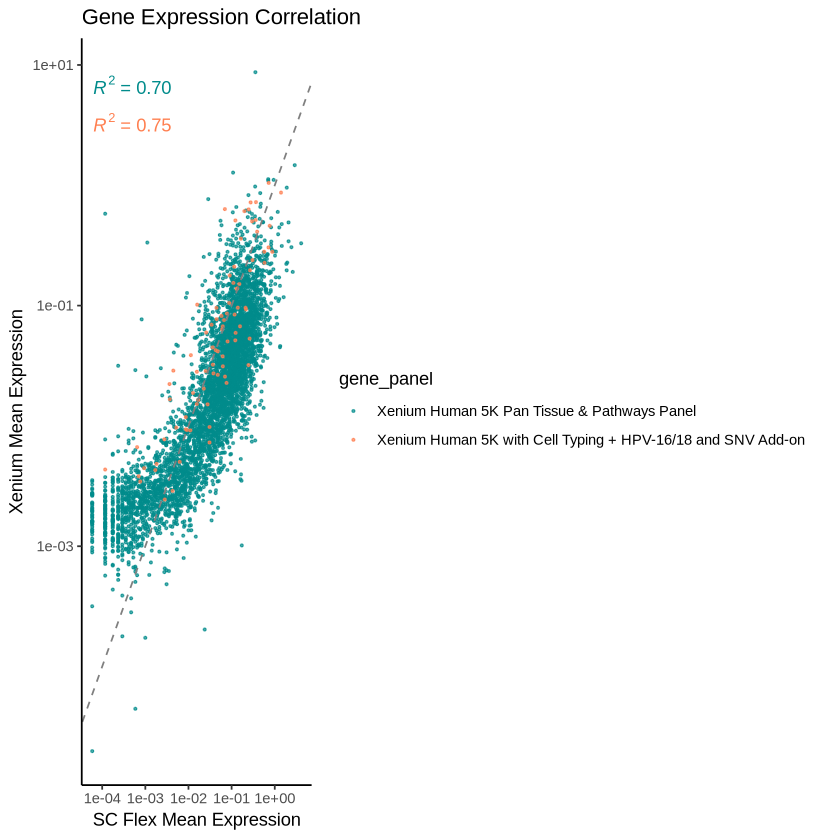

In [7]:
# ============================================
# Cell 4: 相关性分析 - 修复 log10(0) = -Inf
# ============================================

if (file.exists(paths$raw_data$xenium$gene_panel)) {
    cat("📈 计算基因表达相关性...\n")

    get_gex_means <- function(xenium_obj, flex_obj) {
        xen_means <- data.frame(
            mean_counts = rowMeans(xenium_obj[["Xenium"]]$counts),
            gene = rownames(xenium_obj[["Xenium"]]$counts)
        ) %>% arrange(desc(mean_counts)) %>% mutate(Rank = 1:n())

        flex_means <- data.frame(
            mean_counts = rowMeans(flex_obj[["RNA"]]$counts),
            gene = rownames(flex_obj[["RNA"]]$counts)
        ) %>% arrange(desc(mean_counts)) %>% mutate(Rank = 1:n())

        merge(xen_means, flex_means, by = "gene", all.x = TRUE)
    }

    gene_panel <- fromJSON(paths$raw_data$xenium$gene_panel)
    targets <- gene_panel$payload$targets
    panel_source <- setNames(
        data.frame(cbind(targets$source$identity$name, targets$type$data$name)),
        c("gene_panel", "gene")
    )

    merged_means <- get_gex_means(xenium.obj, flex_data.obj)
    merged_means <- merge(merged_means, panel_source, by = "gene", all.x = TRUE) %>%
        na.omit() %>% arrange(gene_panel)

    # 修复：过滤 0 值再做 log10 变换，避免 -Inf 警告
    merged_means_plot <- merged_means %>%
        filter(mean_counts.x > 0, mean_counts.y > 0)

    n_dropped <- nrow(merged_means) - nrow(merged_means_plot)
    if (n_dropped > 0) {
        cat(sprintf("  过滤 %d 个零表达基因（避免 log10(-Inf) warning）\n", n_dropped))
    }

    p_cor <- ggplot(merged_means_plot,
                    aes(x = mean_counts.y, y = mean_counts.x, color = gene_panel)) +
        geom_point(size = 0.5, alpha = 0.7) +
        scale_colour_manual(values = c("darkcyan", "coral")) +
        stat_poly_eq(formula = y ~ x, parse = TRUE) +
        scale_x_log10() + scale_y_log10() +
        xlab("SC Flex Mean Expression") + ylab("Xenium Mean Expression") +
        ggtitle("Gene Expression Correlation") +
        theme_classic() +
        geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50")

    print(p_cor)
    ggsave(file.path(paths$plots$subdirs$quality_control, "gene_expression_correlation.pdf"),
           p_cor, width = 8, height = 6)
    cat("✅ 相关性分析完成\n")
}

🔧 处理 Flex 参考数据...


Normalizing layer: counts

Finding variable features for layer counts

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 17050
Number of edges: 654438

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9345
Number of communities: 20
Elapsed time: 4 seconds


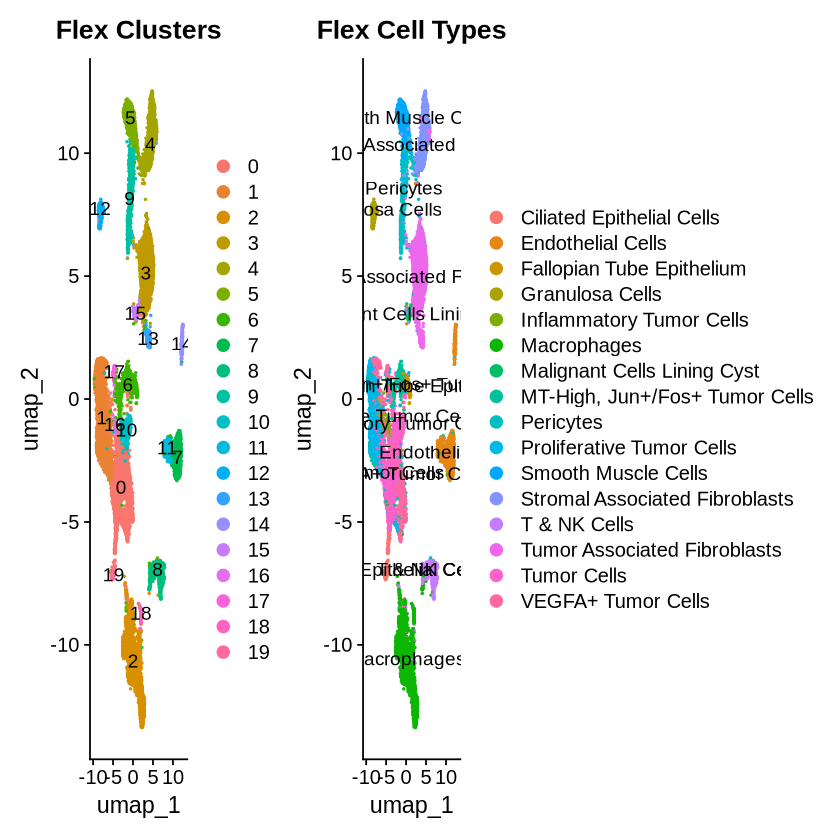

✅ Flex 数据处理完成


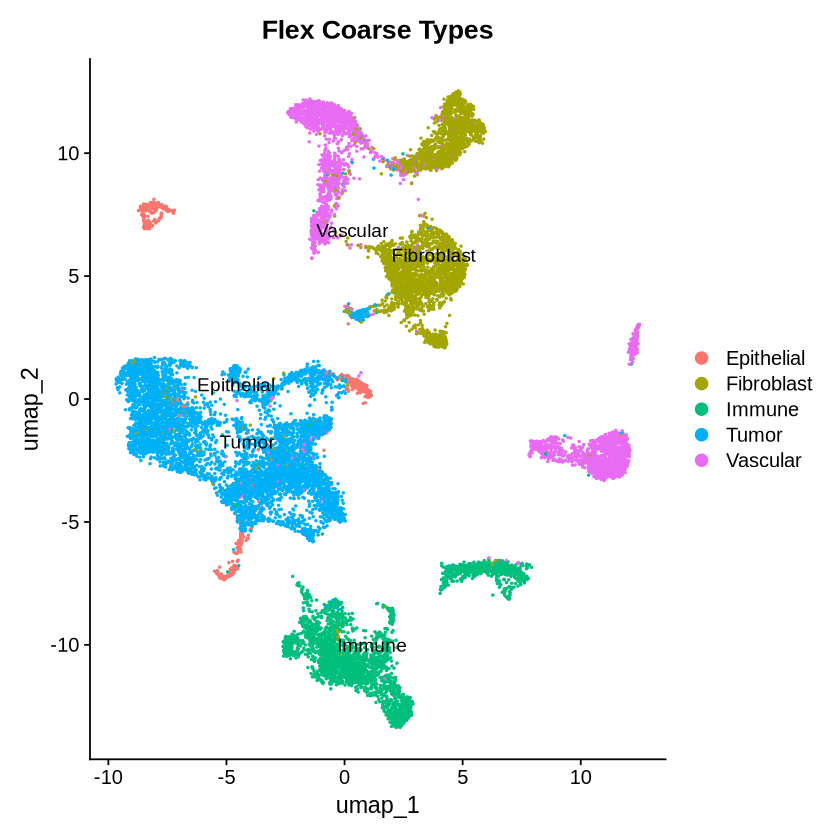

In [8]:
# ============================================
# Cell 5: Flex 处理 - 修复 PC=15 不一致 & UMAP warning
# ============================================

cat("🔧 处理 Flex 参考数据...\n")

DefaultAssay(flex_data.obj) <- "RNA"

flex_data.obj <- NormalizeData(flex_data.obj) %>%
    FindVariableFeatures(nfeatures = 3000) %>%   # 默认 2000，提高到 3000 增强表达力
    ScaleData() %>%
    RunPCA(verbose = FALSE, npcs = params$n_pcs) %>%
    RunUMAP(dims = params$flex_dims,
            verbose = FALSE,
            umap.method = "uwot",     # ← 显式声明，消除警告
            metric = "cosine") %>%
    FindNeighbors(dims = params$flex_dims) %>%
    FindClusters(resolution = 0.5)

p1 <- DimPlot(flex_data.obj, reduction = "umap", group.by = "RNA_snn_res.0.5",
              label = TRUE, pt.size = 0.2) + ggtitle("Flex Clusters")
p2 <- DimPlot(flex_data.obj, reduction = "umap", group.by = "cell_type",
              label = TRUE, pt.size = 0.2) + ggtitle("Flex Cell Types")
p3 <- DimPlot(flex_data.obj, reduction = "umap", group.by = "coarse_type",
              label = TRUE, pt.size = 0.2) + ggtitle("Flex Coarse Types")

print(p1 + p2)
print(p3)

cat("✅ Flex 数据处理完成\n")

In [ ]:
# ============================================
# Cell 6: Xenium 降维聚类 - 修复 UMAP warning
# ============================================

cat("🔧 处理 Xenium 数据（细胞数:", ncol(xenium.obj), "）\n")

DefaultAssay(xenium.obj) <- "Xenium"

xenium.obj <- NormalizeData(xenium.obj) %>%
    FindVariableFeatures() %>%
    ScaleData() %>%
    RunPCA(npcs = params$xenium_npcs, verbose = FALSE) %>%
    RunUMAP(dims = params$xenium_dims,
            verbose = FALSE,
            umap.method = "uwot",     # ← 修复点
            metric = "cosine") %>%
    FindNeighbors(reduction = "pca", dims = params$xenium_dims) %>%
    FindClusters(resolution = params$xenium_resolution,
                 cluster.name = params$xenium_cluster_name)

p_umap_xenium <- DimPlot(xenium.obj, reduction = "umap",
                          group.by = params$xenium_cluster_name,
                          label = TRUE, raster = TRUE) +
    ggtitle("Xenium UMAP Clusters")
print(p_umap_xenium)

cat("✅ Xenium 处理完成 - 共", length(unique(xenium.obj@meta.data[[params$xenium_cluster_name]])), "个聚类\n")

🔧 处理 Xenium 数据（细胞数: 403651 ）


Normalizing layer: counts

Finding variable features for layer counts

Computing nearest neighbor graph

Computing SNN



In [ ]:
# ============================================
# Cell 7: 层级化标签转移 - 关键升级
# 第一步：5 个粗类的标签转移（高置信度）
# 第二步：在每个粗类内部做精细亚型转移
# ============================================

cat("\n🎯 ========== 层级化标签转移开始 ==========\n")

# ─────────────── 第一阶段：粗类转移 ───────────────
cat("\n📍 阶段 1：粗类转移（5 个粗类）\n")

run_coarse_transfer <- function() {
    cat("  - 寻找粗类锚点...\n")
    Idents(flex_data.obj) <- "coarse_type"

    anchors_coarse <- FindTransferAnchors(
        reference = flex_data.obj,
        query     = xenium.obj,
        normalization.method = "LogNormalize",
        reference.assay      = "RNA",
        query.assay          = "Xenium",
        reduction            = "pcaproject",     # 比 cca 快且对稀疏数据更好
        reference.reduction  = "pca",            # 复用已计算 PCA
        dims                 = params$transfer_dims,
        k.filter             = params$transfer_k_filter,
        k.score              = params$transfer_k_score,
        verbose              = TRUE
    )

    cat("  - 转移粗类标签...\n")
    predictions_coarse <- TransferData(
        anchorset = anchors_coarse,
        refdata   = flex_data.obj$coarse_type,
        weight.reduction = xenium.obj[["pca"]],   # 用 query PCA 加权
        dims = params$transfer_dims,
        k.weight = params$transfer_k_weight
    )

    list(anchors = anchors_coarse, predictions = predictions_coarse)
}

# 缓存机制：跑一次后自动复用
if (file.exists(paths$cache$predictions_coarse)) {
    cat("  📦 从缓存加载粗类预测...\n")
    coarse_result <- readRDS(paths$cache$predictions_coarse)
} else {
    coarse_result <- run_coarse_transfer()
    saveRDS(coarse_result, paths$cache$predictions_coarse)
}

predictions_coarse <- coarse_result$predictions

# 写入元数据
xenium.obj$coarse_predicted_id    <- predictions_coarse$predicted.id
xenium.obj$coarse_predicted_score <- predictions_coarse$prediction.score.max

cat("\n  ✅ 粗类转移完成。各粗类置信度:\n")
coarse_summary <- xenium.obj@meta.data %>%
    as.data.frame() %>%
    group_by(coarse_predicted_id) %>%
    summarise(n = n(),
              mean_score = round(mean(coarse_predicted_score), 3),
              median_score = round(median(coarse_predicted_score), 3),
              .groups = "drop") %>%
    arrange(desc(mean_score))
print(coarse_summary)

# ─────────────── 第二阶段：精细亚型转移 ───────────────
cat("\n📍 阶段 2：每个粗类内部做精细亚型转移\n")

run_fine_transfer_per_coarse <- function(coarse_name, fine_subtypes) {
    cat(sprintf("\n  ── 处理粗类: %s (%d 亚型) ──\n",
                coarse_name, length(fine_subtypes)))

    # 1. 取出该粗类的 Flex 参考细胞
    flex_subset_cells <- WhichCells(flex_data.obj,
                                    expression = coarse_type == coarse_name)
    if (length(flex_subset_cells) < 50) {
        cat(sprintf("    ⚠️ 参考细胞数过少 (%d)，跳过精细转移\n",
                    length(flex_subset_cells)))
        return(NULL)
    }
    flex_sub <- subset(flex_data.obj, cells = flex_subset_cells)

    # 仅 1 个亚型时无需转移
    if (length(fine_subtypes) == 1) {
        cat(sprintf("    ℹ️ 仅 1 个亚型，直接赋值\n"))
        # 取出 Xenium 中粗类预测为该粗类的细胞
        query_cells <- WhichCells(xenium.obj,
                                  expression = coarse_predicted_id == coarse_name)
        if (length(query_cells) == 0) return(NULL)
        return(data.frame(
            cell_id = query_cells,
            fine_predicted_id = fine_subtypes[1],
            fine_predicted_score = xenium.obj@meta.data[query_cells, "coarse_predicted_score"]
        ))
    }

    # 2. 重新做 PCA（仅在该粗类内）
    cat("    重新对子集做 PCA...\n")
    DefaultAssay(flex_sub) <- "RNA"
    flex_sub <- NormalizeData(flex_sub, verbose = FALSE) %>%
        FindVariableFeatures(verbose = FALSE) %>%
        ScaleData(verbose = FALSE) %>%
        RunPCA(verbose = FALSE, npcs = min(30, length(flex_subset_cells) - 1))

    # 3. 取出 Xenium 中该粗类的细胞
    query_cells <- WhichCells(xenium.obj,
                              expression = coarse_predicted_id == coarse_name)
    if (length(query_cells) < 10) {
        cat(sprintf("    ⚠️ 查询细胞数过少 (%d)，跳过\n", length(query_cells)))
        return(NULL)
    }
    cat(sprintf("    Flex 参考: %d, Xenium 查询: %d\n",
                length(flex_subset_cells), length(query_cells)))

    xenium_sub <- subset(xenium.obj, cells = query_cells)
    DefaultAssay(xenium_sub) <- "Xenium"
    xenium_sub <- NormalizeData(xenium_sub, verbose = FALSE) %>%
        FindVariableFeatures(verbose = FALSE) %>%
        ScaleData(verbose = FALSE)

    n_dim <- min(30, ncol(flex_sub[["pca"]]) - 1)

    # 4. 重新找锚点
    Idents(flex_sub) <- "cell_type"
    anchors_fine <- FindTransferAnchors(
        reference = flex_sub,
        query     = xenium_sub,
        normalization.method = "LogNormalize",
        reference.assay      = "RNA",
        query.assay          = "Xenium",
        reduction            = "pcaproject",
        reference.reduction  = "pca",
        dims                 = 1:n_dim,
        k.filter             = min(params$transfer_k_filter,
                                   floor(length(flex_subset_cells) * 0.5)),
        k.score              = min(params$transfer_k_score, 30),
        verbose              = FALSE
    )

    # 5. 转移精细标签
    cat("    转移精细标签...\n")
    predictions_fine <- TransferData(
        anchorset = anchors_fine,
        refdata   = flex_sub$cell_type,
        weight.reduction = "pcaproject",   # 用 query PCA 加权
        dims = 1:n_dim,
        k.weight = min(params$transfer_k_weight, 30)
    )

    cat(sprintf("    ✅ %s 完成 (平均置信度: %.3f)\n",
                coarse_name, mean(predictions_fine$prediction.score.max)))

    data.frame(
        cell_id = rownames(predictions_fine),
        fine_predicted_id    = predictions_fine$predicted.id,
        fine_predicted_score = predictions_fine$prediction.score.max,
        stringsAsFactors = FALSE
    )
}

# 缓存机制
if (file.exists(paths$cache$predictions_fine)) {
    cat("  📦 从缓存加载精细预测...\n")
    fine_predictions_list <- readRDS(paths$cache$predictions_fine)
} else {
    fine_predictions_list <- list()
    for (coarse in names(celltype_hierarchy)) {
        fine_predictions_list[[coarse]] <- run_fine_transfer_per_coarse(
            coarse, celltype_hierarchy[[coarse]]
        )
    }
    saveRDS(fine_predictions_list, paths$cache$predictions_fine)
}

# 合并所有粗类的精细预测
fine_predictions_all <- do.call(rbind,
    Filter(Negate(is.null), fine_predictions_list))
rownames(fine_predictions_all) <- fine_predictions_all$cell_id

cat(sprintf("\n  ✅ 精细转移完成，共 %d 个细胞\n", nrow(fine_predictions_all)))

# 写入元数据
all_cells <- colnames(xenium.obj)
xenium.obj$fine_predicted_id <- fine_predictions_all[all_cells, "fine_predicted_id"]
xenium.obj$fine_predicted_score <- fine_predictions_all[all_cells, "fine_predicted_score"]

# 综合置信度：粗类置信度 × 精细置信度（几何平均）
# 这样若任一阶段置信度低，最终也低；两阶段都高才高
xenium.obj$combined_score <- sqrt(
    xenium.obj$coarse_predicted_score * xenium.obj$fine_predicted_score
)

cat("\n  ✅ 层级化转移完成。各精细类型置信度:\n")
fine_summary <- xenium.obj@meta.data %>%
    as.data.frame() %>%
    filter(!is.na(fine_predicted_id)) %>%
    group_by(fine_predicted_id) %>%
    summarise(
        n = n(),
        mean_coarse  = round(mean(coarse_predicted_score, na.rm = TRUE), 3),
        mean_fine    = round(mean(fine_predicted_score, na.rm = TRUE), 3),
        mean_combined = round(mean(combined_score, na.rm = TRUE), 3),
        .groups = "drop"
    ) %>%
    arrange(desc(mean_combined))
print(fine_summary)

In [ ]:
# ============================================
# Cell 8: 空间平滑 + Marker 校验
# ============================================

cat("\n🌐 ========== 空间一致性平滑 ==========\n")

# ─────────────── 8.1 提取空间坐标 ───────────────
cat("\n📍 步骤 8.1: 提取空间坐标\n")

coords_df <- GetTissueCoordinates(xenium.obj)
# 兼容不同 Seurat 版本的坐标列名
coord_cols <- intersect(c("cell", "x", "y"), colnames(coords_df))
if ("cell" %in% colnames(coords_df)) {
    rownames(coords_df) <- coords_df$cell
}

# 添加到元数据
xenium.obj$x_centroid <- coords_df[colnames(xenium.obj), "x"]
xenium.obj$y_centroid <- coords_df[colnames(xenium.obj), "y"]

cat(sprintf("  坐标范围 x: [%.1f, %.1f]\n",
            min(xenium.obj$x_centroid, na.rm = TRUE),
            max(xenium.obj$x_centroid, na.rm = TRUE)))
cat(sprintf("  坐标范围 y: [%.1f, %.1f]\n",
            min(xenium.obj$y_centroid, na.rm = TRUE),
            max(xenium.obj$y_centroid, na.rm = TRUE)))

# 备份坐标
write.csv(
    data.frame(cell_id = colnames(xenium.obj),
               x_centroid = xenium.obj$x_centroid,
               y_centroid = xenium.obj$y_centroid),
    paths$backup$coordinates, row.names = FALSE
)

# ─────────────── 8.2 空间最近邻 ───────────────
cat(sprintf("\n📍 步骤 8.2: 计算空间 k=%d 最近邻\n", params$spatial_k))

valid_idx <- which(!is.na(xenium.obj$x_centroid) &
                   !is.na(xenium.obj$y_centroid) &
                   !is.na(xenium.obj$fine_predicted_id))

coords_mat <- as.matrix(xenium.obj@meta.data[valid_idx,
                                              c("x_centroid", "y_centroid")])
cat(sprintf("  对 %d 个有效细胞计算最近邻...\n", length(valid_idx)))

nn_result <- get.knn(coords_mat, k = params$spatial_k)
# nn_result$nn.index 是 n × k 的索引矩阵（基于 valid_idx 内部位置）

cat("  ✅ 最近邻计算完成\n")

# ─────────────── 8.3 空间平滑 ───────────────
cat("\n📍 步骤 8.3: 对低置信度细胞做空间平滑\n")

fine_id_vec    <- xenium.obj$fine_predicted_id[valid_idx]
fine_score_vec <- xenium.obj$fine_predicted_score[valid_idx]
combined_vec   <- xenium.obj$combined_score[valid_idx]

smoothed_id    <- fine_id_vec
smoothed_score <- combined_vec

# 需要平滑的细胞：综合置信度低于阈值
to_smooth <- which(combined_vec < params$spatial_threshold)
cat(sprintf("  待平滑细胞: %d / %d (%.1f%%)\n",
            length(to_smooth), length(combined_vec),
            length(to_smooth) / length(combined_vec) * 100))

n_updated <- 0
n_boosted <- 0

# 进度条
pb <- txtProgressBar(min = 0, max = length(to_smooth), style = 3)

for (j in seq_along(to_smooth)) {
    i <- to_smooth[j]
    nbr_idx <- nn_result$nn.index[i, ]
    nbr_ids    <- fine_id_vec[nbr_idx]
    nbr_scores <- combined_vec[nbr_idx]

    # 仅考虑高置信度邻居
    hc_mask <- nbr_scores >= params$spatial_threshold
    if (sum(hc_mask) < 5) {
        # 高置信度邻居不足 5 个，跳过
        if (j %% 5000 == 0) setTxtProgressBar(pb, j)
        next
    }

    hc_ids <- nbr_ids[hc_mask]
    tab <- sort(table(hc_ids), decreasing = TRUE)
    most_common <- names(tab)[1]
    consensus_frac <- as.numeric(tab[1]) / sum(hc_mask)

    if (consensus_frac >= params$spatial_consensus) {
        # 满足共识：更新标签 + 提升置信度
        if (most_common != fine_id_vec[i]) {
            n_updated <- n_updated + 1
            smoothed_id[i] <- most_common
        }
        # 新分数 = 原分数 × (1-w) + 共识比例 × w，其中 w = 0.6
        boosted <- combined_vec[i] * 0.4 + consensus_frac * 0.6
        smoothed_score[i] <- max(combined_vec[i], boosted)
        n_boosted <- n_boosted + 1
    }
    if (j %% 5000 == 0) setTxtProgressBar(pb, j)
}
setTxtProgressBar(pb, length(to_smooth))
close(pb)

cat(sprintf("\n  ✅ 标签更新: %d\n", n_updated))
cat(sprintf("  ✅ 置信度提升: %d\n", n_boosted))
cat(sprintf("  平均置信度: %.3f → %.3f\n",
            mean(combined_vec), mean(smoothed_score)))

# 写回元数据
xenium.obj$smoothed_predicted_id    <- NA_character_
xenium.obj$smoothed_predicted_score <- NA_real_
xenium.obj$smoothed_predicted_id[valid_idx]    <- smoothed_id
xenium.obj$smoothed_predicted_score[valid_idx] <- smoothed_score

# ─────────────── 8.4 Marker 模块分数校验 ───────────────
cat("\n📍 步骤 8.4: Marker 模块分数校验\n")

# 仅保留 Xenium panel 中存在的 marker
available_genes <- rownames(xenium.obj)
canonical_markers_avail <- lapply(canonical_markers, function(g) {
    intersect(g, available_genes)
})

# 过滤掉 marker 全部缺失的细胞类型
canonical_markers_avail <- Filter(function(g) length(g) > 0,
                                  canonical_markers_avail)

cat(sprintf("  %d / %d 细胞类型有可用 marker\n",
            length(canonical_markers_avail), length(canonical_markers)))

# 计算 module score
xenium.obj <- AddModuleScore(
    xenium.obj,
    features = canonical_markers_avail,
    name = "marker_score_",
    seed = params$seed
)

# Seurat AddModuleScore 加后缀 _1, _2, ...
score_cols <- paste0("marker_score_", seq_along(canonical_markers_avail))
score_cols_avail <- score_cols[score_cols %in% colnames(xenium.obj@meta.data)]

# 重命名为细胞类型名
celltypes_avail <- names(canonical_markers_avail)
names(score_cols_avail) <- celltypes_avail[seq_along(score_cols_avail)]

cat("  ✅ 模块分数计算完成\n")

# 校验：每个细胞 predicted type 的 marker 分数是否处于 top 30%
cat("\n  Marker 校验结果:\n")
for (ct in celltypes_avail) {
    score_col <- score_cols_avail[[ct]]
    if (is.null(score_col) || !(score_col %in% colnames(xenium.obj@meta.data))) next

    cells_predicted <- which(xenium.obj$smoothed_predicted_id == ct)
    if (length(cells_predicted) == 0) next

    all_scores <- xenium.obj@meta.data[[score_col]]
    threshold <- quantile(all_scores, 0.7, na.rm = TRUE)
    pass_rate <- mean(all_scores[cells_predicted] >= threshold, na.rm = TRUE)

    cat(sprintf("    %-35s  通过率: %.1f%% (n=%d)\n",
                ct, pass_rate * 100, length(cells_predicted)))
}

cat("\n✅ 空间平滑 + Marker 校验完成\n")

In [ ]:
# ============================================
# Cell 9: 综合打分 + 导出（修复 NA & summarise warning）
# ============================================

cat("\n📤 ========== 综合打分与导出 ==========\n")

# ─────────────── 9.1 最终预测 ───────────────
# predicted.id = 平滑后的标签
# prediction.score.max = 平滑后的综合分数
xenium.obj$predicted.id          <- xenium.obj$smoothed_predicted_id
xenium.obj$prediction.score.max  <- xenium.obj$smoothed_predicted_score

# 低置信度细胞标记为 Unassigned（可选，按需注释掉）
unassigned_mask <- !is.na(xenium.obj$prediction.score.max) &
                   xenium.obj$prediction.score.max < params$unassigned_threshold

n_unassigned <- sum(unassigned_mask)
cat(sprintf("\n  ⚠️ 综合分数 < %.2f 的细胞数: %d (%.2f%%)\n",
            params$unassigned_threshold, n_unassigned,
            n_unassigned / ncol(xenium.obj) * 100))

# 你可以选择是否将极低置信度细胞标记为 Unassigned
# 默认保留原标签，仅在导出时通过 confidence_tier 区分
# 如果想标记，取消下一行注释：
xenium.obj$predicted.id[unassigned_mask] <- "Unassigned"

# 置信度分级
xenium.obj$confidence_tier <- case_when(
    is.na(xenium.obj$prediction.score.max)            ~ "missing",
    xenium.obj$prediction.score.max >= params$confidence_high   ~ "high",
    xenium.obj$prediction.score.max >= params$confidence_medium ~ "medium",
    TRUE ~ "low"
)

cat("\n  置信度分级分布:\n")
print(table(xenium.obj$confidence_tier))

# ─────────────── 9.2 导出基础 cell_groups.csv ───────────────
cat("\n📤 步骤 9.2: 导出 cell_groups.csv\n")

export_basic <- data.frame(
    cell_id              = colnames(xenium.obj),
    cluster              = xenium.obj@meta.data[[params$xenium_cluster_name]],
    predicted_cell_type  = xenium.obj$predicted.id,
    coarse_type          = xenium.obj$coarse_predicted_id,
    coarse_score         = round(xenium.obj$coarse_predicted_score, 4),
    fine_score           = round(xenium.obj$fine_predicted_score, 4),
    prediction_score     = round(xenium.obj$prediction.score.max, 4),
    confidence_tier      = xenium.obj$confidence_tier,
    stringsAsFactors = FALSE
)

write.csv(export_basic, paths$predictions$main, row.names = FALSE)
cat(sprintf("  ✅ 已导出: %s (%d 行)\n",
            paths$predictions$main, nrow(export_basic)))

# ─────────────── 9.3 完整预测分数（修复 NaN 问题）───────────────
cat("\n📤 步骤 9.3: 导出完整预测分数\n")

# 构建完整分数矩阵：每个细胞 × 每个细胞类型的分数
# 修复点：原版用 make.names 导致 "T & NK Cells" → "T...NK.Cells"
# 在某些下游统计中无法匹配。这里直接用细胞类型原始名作为列名

all_celltypes <- unique(unlist(celltype_hierarchy))

# 初始化分数矩阵
score_matrix <- matrix(0, nrow = ncol(xenium.obj), ncol = length(all_celltypes),
                       dimnames = list(colnames(xenium.obj), all_celltypes))

# 填入：每个细胞，其 predicted_cell_type 对应列设为 prediction_score
# 这是简化版（仅最大分数），完整版需要保存 prediction_scores 矩阵
for (i in seq_along(xenium.obj$predicted.id)) {
    pid <- xenium.obj$predicted.id[i]
    if (!is.na(pid) && pid %in% all_celltypes) {
        score_matrix[i, pid] <- xenium.obj$prediction.score.max[i]
    }
}

export_full <- cbind(
    data.frame(cell_id = colnames(xenium.obj)),
    as.data.frame(score_matrix),
    data.frame(
        predicted_cell_type = xenium.obj$predicted.id,
        prediction_score    = xenium.obj$prediction.score.max,
        confidence_tier     = xenium.obj$confidence_tier
    )
)

write.csv(export_full, paths$predictions$full, row.names = FALSE)
cat(sprintf("  ✅ 已导出: %s (%d 行 × %d 列)\n",
            paths$predictions$full, nrow(export_full), ncol(export_full)))

# ─────────────── 9.4 GNN 数据导出 ───────────────
cat("\n📤 步骤 9.4: 导出 GNN 训练数据\n")

# PCA 嵌入
pca_embed <- Embeddings(xenium.obj, "pca")[, 1:50]

gnn_data <- data.frame(
    cell_id              = colnames(xenium.obj),
    x_centroid           = xenium.obj$x_centroid,
    y_centroid           = xenium.obj$y_centroid,
    predicted_cell_type  = xenium.obj$predicted.id,
    prediction_score     = round(xenium.obj$prediction.score.max, 4),
    confidence_tier      = xenium.obj$confidence_tier,
    cluster              = xenium.obj@meta.data[[params$xenium_cluster_name]]
)
gnn_data <- cbind(gnn_data, as.data.frame(pca_embed))

# 过滤缺失坐标
n_before <- nrow(gnn_data)
gnn_data <- gnn_data[!is.na(gnn_data$x_centroid) & !is.na(gnn_data$y_centroid), ]
n_dropped <- n_before - nrow(gnn_data)
if (n_dropped > 0) cat(sprintf("  过滤 %d 个缺失坐标的细胞\n", n_dropped))

write.csv(gnn_data, paths$predictions$for_gnn, row.names = FALSE)
cat(sprintf("  ✅ 已导出: %s (%d 行)\n",
            paths$predictions$for_gnn, nrow(gnn_data)))

# ─────────────── 9.5 Seurat 对比导出 ───────────────
cat("\n📤 步骤 9.5: 导出 Seurat LT 对比文件\n")

lt_export <- data.frame(
    cell_id          = colnames(xenium.obj),
    x                = xenium.obj$x_centroid,
    y                = xenium.obj$y_centroid,
    predicted_id     = xenium.obj$predicted.id,
    prediction_score = round(xenium.obj$prediction.score.max, 4),
    coarse_type      = xenium.obj$coarse_predicted_id,
    coarse_score     = round(xenium.obj$coarse_predicted_score, 4),
    confidence_tier  = xenium.obj$confidence_tier,
    stringsAsFactors = FALSE
)
lt_export <- lt_export[!is.na(lt_export$x) & !is.na(lt_export$y), ]

write.csv(lt_export, paths$seurat_lt_csv, row.names = FALSE)
cat(sprintf("  ✅ 已导出: %s (%d 行)\n",
            paths$seurat_lt_csv, nrow(lt_export)))

# ─────────────── 9.6 保存 Seurat 对象 ───────────────
saveRDS(xenium.obj, paths$predictions$seurat_objects$xenium_annotated)
saveRDS(flex_data.obj, paths$predictions$seurat_objects$flex_reference)

# ─────────────── 9.7 详细统计报告（修复 min() warning）───────────────
cat("\n📊 步骤 9.7: 生成统计报告\n")

# 修复点：min/max 在空集时返回 Inf/-Inf，需显式处理
safe_stat <- function(x, fn) {
    if (length(x) == 0 || all(is.na(x))) return(NA_real_)
    fn(x, na.rm = TRUE)
}

stats_by_type <- export_basic %>%
    group_by(predicted_cell_type) %>%
    summarise(
        n_cells       = n(),
        mean_score    = safe_stat(prediction_score, mean),
        median_score  = safe_stat(prediction_score, median),
        min_score     = safe_stat(prediction_score, min),
        max_score     = safe_stat(prediction_score, max),
        sd_score      = safe_stat(prediction_score, sd),
        high_conf_pct = mean(prediction_score >= params$confidence_high,
                             na.rm = TRUE) * 100,
        .groups = "drop"
    ) %>%
    arrange(desc(mean_score))

cat("\n  各细胞类型置信度统计:\n")
print(stats_by_type)

# 写入报告文件
sink(paths$reports$stats)
cat("=== 标签转移预测统计报告（层级化 + 空间平滑版）===\n")
cat("生成时间:", format(Sys.time()), "\n")
cat("总细胞数:", nrow(export_basic), "\n\n")
cat("置信度分级分布:\n")
print(table(export_basic$confidence_tier))
cat("\n各细胞类型置信度统计:\n")
print(stats_by_type)
cat("\n粗类置信度统计:\n")
print(coarse_summary)
sink()

cat("\n✅ 统计报告已保存:", paths$reports$stats, "\n")

# ─────────────── 9.8 摘要 ───────────────
cat("\n", strrep("━", 60), "\n")
cat("📊 导出完成摘要\n")
cat(strrep("━", 60), "\n")
cat("📁 输出文件:\n")
cat("  1. 基础预测:", paths$predictions$main, "\n")
cat("  2. 完整预测分数:", paths$predictions$full, "\n")
cat("  3. GNN 数据:", paths$predictions$for_gnn, "\n")
cat("  4. Seurat 对象:", paths$predictions$seurat_objects$xenium_annotated, "\n")
cat("  5. Seurat LT CSV:", paths$seurat_lt_csv, "\n")
cat("  6. 统计报告:", paths$reports$stats, "\n")

cat("\n📈 关键指标:\n")
cat(sprintf("  总细胞数: %d\n", ncol(xenium.obj)))
cat(sprintf("  平均综合置信度: %.3f\n",
            mean(xenium.obj$prediction.score.max, na.rm = TRUE)))
cat(sprintf("  高置信度 (≥%.2f) 细胞占比: %.1f%%\n",
            params$confidence_high,
            mean(xenium.obj$prediction.score.max >= params$confidence_high,
                 na.rm = TRUE) * 100))
cat(strrep("━", 60), "\n")

In [ ]:
# ============================================
# Cell 10: 论文图表
# ============================================

cat("📈 生成论文图表...\n")

# A. scRNA UMAP - cell_type
p_umap_scrna <- DimPlot(flex_data.obj, reduction = "umap", group.by = "cell_type",
                        label = TRUE, repel = TRUE, pt.size = 0.3) +
    ggtitle("Flex scRNA-seq: Cell Types (UMAP)") +
    theme(plot.title = element_text(hjust = 0.5))
ggsave(file.path(paths$plots$subdirs$annotation, "scrna_umap_celltypes.pdf"),
       p_umap_scrna, width = 10, height = 8)

# A2. scRNA UMAP - coarse_type
p_umap_coarse <- DimPlot(flex_data.obj, reduction = "umap", group.by = "coarse_type",
                         label = TRUE, repel = TRUE, pt.size = 0.3) +
    ggtitle("Flex scRNA-seq: Coarse Types (UMAP)") +
    theme(plot.title = element_text(hjust = 0.5))
ggsave(file.path(paths$plots$subdirs$annotation, "scrna_umap_coarse.pdf"),
       p_umap_coarse, width = 10, height = 8)

# B. Xenium 空间图 - 精细预测
p_spatial_fine <- ImageDimPlot(xenium.obj, fov = "fov",
                                group.by = "predicted.id",
                                size = 0.4, dark.background = FALSE) +
    ggtitle("Xenium: Predicted Fine Cell Types (Hierarchical + Smoothed)") +
    theme(plot.title = element_text(hjust = 0.5),
          legend.text = element_text(size = 7))
ggsave(file.path(paths$plots$subdirs$spatial, "xenium_spatial_fine.pdf"),
       p_spatial_fine, width = 12, height = 10)

# B2. Xenium 空间图 - 粗类预测
p_spatial_coarse <- ImageDimPlot(xenium.obj, fov = "fov",
                                  group.by = "coarse_predicted_id",
                                  size = 0.4, dark.background = FALSE) +
    ggtitle("Xenium: Predicted Coarse Cell Types") +
    theme(plot.title = element_text(hjust = 0.5))
ggsave(file.path(paths$plots$subdirs$spatial, "xenium_spatial_coarse.pdf"),
       p_spatial_coarse, width = 12, height = 10)

# B3. Xenium 空间图 - 置信度
p_spatial_conf <- ImageFeaturePlot(xenium.obj, fov = "fov",
                                    features = "prediction.score.max",
                                    size = 0.3) +
    scale_fill_viridis_c(option = "plasma", name = "Confidence", limits = c(0, 1)) +
    ggtitle("Xenium: Prediction Confidence (spatial)") +
    theme(plot.title = element_text(hjust = 0.5))
ggsave(file.path(paths$plots$subdirs$spatial, "xenium_spatial_confidence.pdf"),
       p_spatial_conf, width = 12, height = 10)

# C. 比例对比
scrna_prop <- data.frame(
    cell_type  = names(table(flex_data.obj$cell_type)),
    proportion = as.numeric(table(flex_data.obj$cell_type)) / ncol(flex_data.obj),
    source     = "scRNA (Flex)"
)
xen_prop <- data.frame(
    cell_type  = names(table(xenium.obj$predicted.id)),
    proportion = as.numeric(table(xenium.obj$predicted.id)) / ncol(xenium.obj),
    source     = "Xenium (Hierarchical LT)"
)
prop_combined <- rbind(scrna_prop, xen_prop)

p_proportion <- ggplot(prop_combined,
       aes(x = source, y = proportion, fill = cell_type)) +
    geom_bar(stat = "identity", width = 0.6) +
    scale_y_continuous(labels = percent_format()) +
    labs(title = "Cell Type Proportion: scRNA vs Xenium",
         x = "", y = "Proportion") +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5))
ggsave(file.path(paths$plots$subdirs$validation, "celltype_proportion_comparison.pdf"),
       p_proportion, width = 9, height = 6)

# D. 各细胞类型置信度（修复 NaN/Inf）
score_df <- xenium.obj@meta.data %>%
    as.data.frame() %>%
    filter(!is.na(prediction.score.max) & !is.na(predicted.id)) %>%
    group_by(predicted.id) %>%
    summarise(
        mean_score = mean(prediction.score.max),
        se_score   = sd(prediction.score.max) / sqrt(n()),
        n_cells    = n(),
        .groups    = "drop"
    ) %>%
    arrange(desc(mean_score))

p_confidence <- ggplot(score_df,
       aes(x = reorder(predicted.id, mean_score),
           y = mean_score, fill = predicted.id)) +
    geom_col(show.legend = FALSE) +
    geom_errorbar(aes(ymin = mean_score - se_score,
                      ymax = mean_score + se_score),
                  width = 0.3, color = "gray40") +
    geom_text(aes(label = paste0("n=", n_cells)),
              hjust = -0.15, size = 2.8) +
    geom_hline(yintercept = params$confidence_high,
               linetype = "dashed", color = "red") +
    scale_fill_viridis_d(option = "plasma") +
    scale_y_continuous(limits = c(0, 1.1), expand = c(0, 0)) +
    coord_flip() +
    labs(title = "Mean Prediction Score by Cell Type (Hierarchical + Smoothed)",
         subtitle = sprintf("红线 = 高置信度阈值 %.2f", params$confidence_high),
         x = "", y = "Mean Confidence") +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5),
          plot.subtitle = element_text(hjust = 0.5))

ggsave(file.path(paths$plots$subdirs$validation, "prediction_confidence_by_type.pdf"),
       p_confidence, width = 9, height = 7)
print(p_confidence)

# E. Xenium QC 空间图
p_qc_spatial <- ImageFeaturePlot(xenium.obj, fov = "fov",
                                  features = "nCount_Xenium_log",
                                  size = 0.3) +
    scale_fill_viridis_c(option = "magma", name = "log(nCount)") +
    ggtitle("Xenium Transcript Count per Cell (spatial)") +
    theme(plot.title = element_text(hjust = 0.5))
ggsave(file.path(paths$plots$subdirs$quality_control, "xenium_qc_ncount_spatial.pdf"),
       p_qc_spatial, width = 10, height = 9)

cat("✅ 论文图表完成，保存在:", paths$plots$dir, "\n")